<a href="https://colab.research.google.com/github/seun829/DataScience/blob/main/Unit8/SeunLee_Unit8Proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting The Number of Bathrooms in a US House Based on Multiple Factors

# Introduction

In this project I will be predicting the number of bathrooms in a house.

I chose this topic because I am interested in house prices and how different attributes of a house influence one another.

Going into this, I expect the most influential factor to be the square feet of the above part of a house.

There is context for why fractions of bathrooms will appear in the data. Fractions do not mean the bathroom was literally broken into pieces. Here is the general guideline:
* 1.00 = full bathroom: toilet, sink, tub/shower
* 0.75 = three-quarter bathroom: usually toilet, sink, shower
* 0.50 = half bathroom: toilet and sink
* 0.25 = quarter bathroom: usually just one fixture

sqft_above + sqft_basement = sqft_living

In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv
import matplotlib.pyplot as plt

In [ ]:
!pip install pymc-bart
import pymc_bart as pmb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.9/179.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.0 MB/s eta 0:00:00


# Data

In [ ]:
house_data = pd.read_csv("https://raw.githubusercontent.com/seun829/DataScience/refs/heads/main/house%20price.csv")

In [ ]:
house_data

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


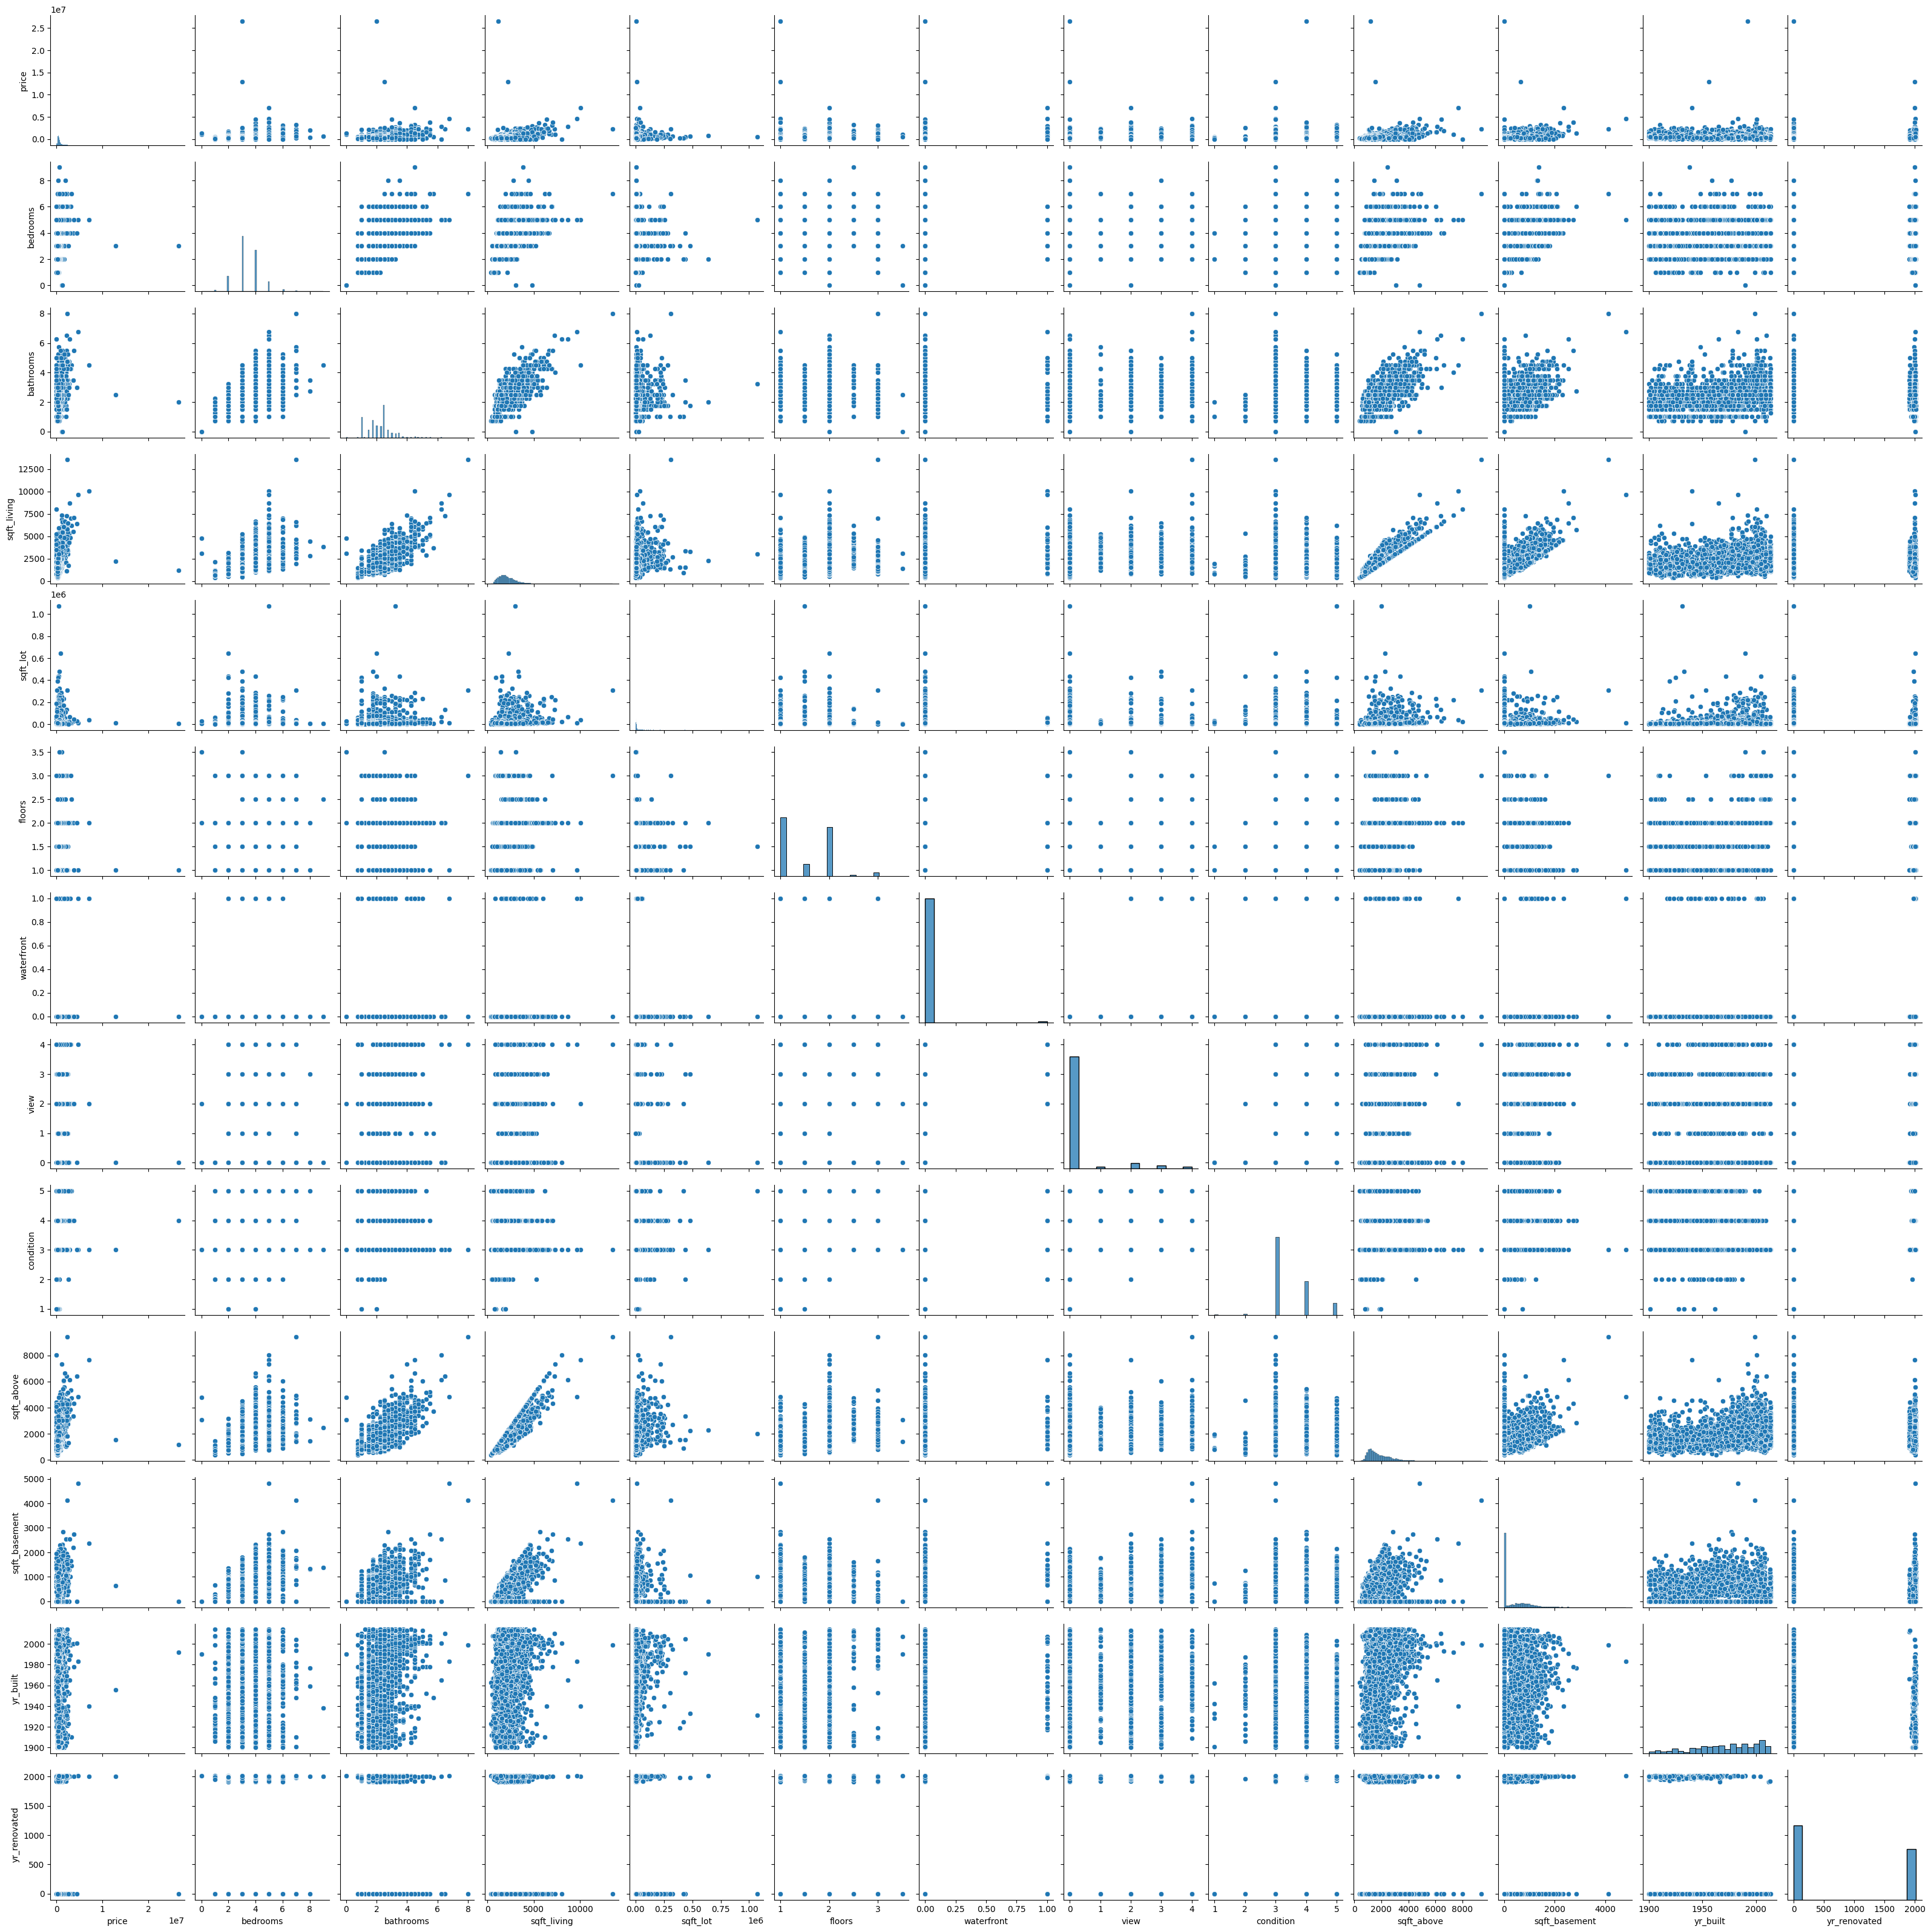

In [ ]:
sns.pairplot(house_data)

Correlations between sqft_living and bathrooms, bedroom, sqft_basement, and sqft_above, and price.

I considered choosing sqft_living but since it is literally just basement and above combined, I felt that there wasn't much insight to be gained.

# Causal Diagram

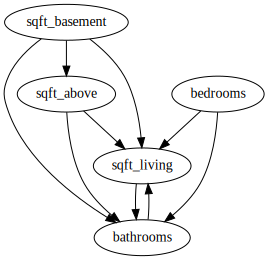

In [15]:
graph = gv.Digraph(comment="house_dag", format="png")
graph.node("sqft_living")
graph.node("sqft_basement")
graph.node("sqft_above")
graph.node("bedrooms")

graph.edge("sqft_basement", "sqft_living")
graph.edge("bedrooms", "sqft_living")
graph.edge("sqft_above", "sqft_living")
graph.edge("sqft_basement", "sqft_above")
graph.edge("bathrooms", "sqft_living")
graph.edge("sqft_living", "bathrooms")
graph.edge("sqft_above", "bathrooms")
graph.edge("sqft_basement", "bathrooms")
graph.edge("bedrooms", "bathrooms")

graph

Based on the pair plots, I took out some of the factors that did not visibly influence other factors. these factors were sqft_lot, view, floors, waterfront,price, etc.

# Reference Model

In [45]:
sdsts_nona = house_data.dropna()

In [46]:
X = sdsts_nona[[
    'bedrooms',
    'sqft_above',
    'sqft_basement',
    'sqft_living'
]]

Y = (
    (sdsts_nona["bathrooms"] - sdsts_nona["bathrooms"].mean())
    / sdsts_nona["bathrooms"].std()
)

In [47]:
with pm.Model() as model_house:
    s = pm.HalfNormal("s", 1)

    mu = pmb.BART("mu", X, Y, m=50)

    y = pm.Normal("y", mu=mu, sigma=s, observed=Y)

    idata_house = pm.sample(compute_convergence_checks=False, progressbar=False)

In [48]:
pm.sample_posterior_predictive(idata_house, model_house, extend_inferencedata=True, progressbar=False)

posterior_mean = idata_house.posterior["mu"]

μ_hdi = az.hdi(ary=idata_house, group="posterior", var_names=["mu"], hdi_prob=0.74)

pps = az.extract(
    idata_house, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


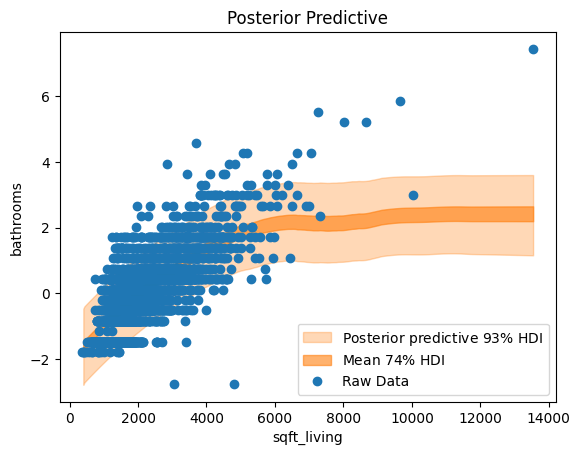

In [49]:
x_plot = X["sqft_living"].to_numpy()
idx = np.argsort(x_plot)

fig, ax = plt.subplots()

az.plot_hdi(
    x=x_plot[idx],
    y=pps[:, idx],
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=x_plot[idx],
    y=posterior_mean.stack(sample=("chain", "draw")).transpose("sample", ...).values[:, idx],
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)

ax.plot(
    sdsts_nona["sqft_living"],
    Y,
    "o",
    c="C0",
    label="Raw Data"
)

ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="sqft_living",
    ylabel="bathrooms"
);

<Axes: ylabel='R²'>

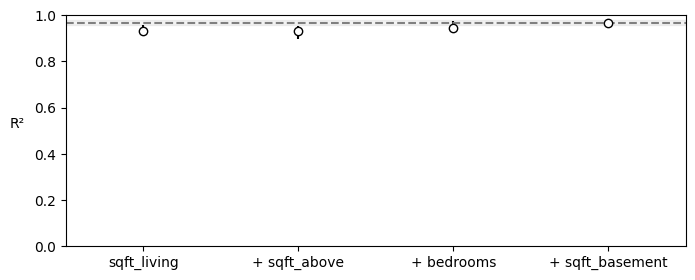

In [50]:
vars = pmb.compute_variable_importance(idata_house, mu, X)
pmb.plot_variable_importance(vars)

# Other Models

Next up, I will do a model excluding sqft_basement, because the correlation isn't very strong, and logically there are less cases involving bathrooms in a basement.

In [51]:
X = sdsts_nona[[
    'bedrooms',
    'sqft_above',
    'sqft_living'
]]

Y = (
    (sdsts_nona["bathrooms"] - sdsts_nona["bathrooms"].mean())
    / sdsts_nona["bathrooms"].std()
)

In [52]:
with pm.Model() as model_house2:
    s = pm.HalfNormal("s", 1)

    mu = pmb.BART("mu", X, Y, m=50)

    y = pm.Normal("y", mu=mu, sigma=s, observed=Y)

    idata_house2 = pm.sample(compute_convergence_checks=False, progressbar=False)

In [53]:
pm.sample_posterior_predictive(idata_house2, model_house2, extend_inferencedata=True, progressbar=False)

posterior_mean = idata_house2.posterior["mu"]

μ_hdi = az.hdi(ary=idata_house2, group="posterior", var_names=["mu"], hdi_prob=0.74)

pps = az.extract(
    idata_house2, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


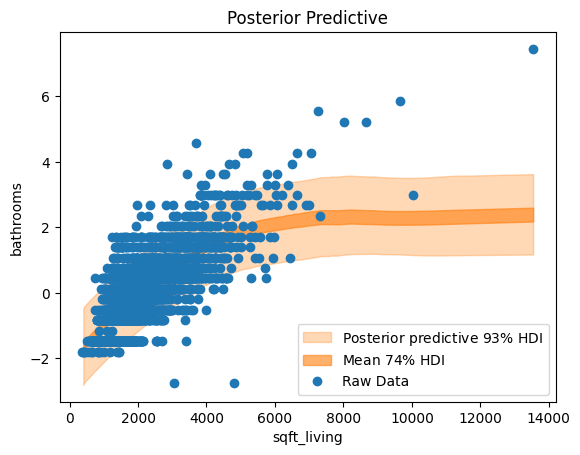

In [54]:
x_plot = X["sqft_living"].to_numpy()
idx = np.argsort(x_plot)

fig, ax = plt.subplots()

az.plot_hdi(
    x=x_plot[idx],
    y=pps[:, idx],
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=x_plot[idx],
    y=posterior_mean.stack(sample=("chain", "draw")).transpose("sample", ...).values[:, idx],
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)

ax.plot(
    sdsts_nona["sqft_living"],
    Y,
    "o",
    c="C0",
    label="Raw Data"
)

ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="sqft_living",
    ylabel="bathrooms"
);

Now I will try with more trees, setting m to 100 to see whether it overfits or performs better.

In [30]:
X = sdsts_nona[[
    'bedrooms',
    'sqft_above',
    'sqft_living'
]]

Y = (
    (sdsts_nona["bathrooms"] - sdsts_nona["bathrooms"].mean())
    / sdsts_nona["bathrooms"].std()
)

In [32]:
with pm.Model() as model_house3:
    s = pm.HalfNormal("s", 1)

    mu = pmb.BART("mu", X, Y, m=100)

    y = pm.Normal("y", mu=mu, sigma=s, observed=Y)

    idata_house3 = pm.sample(compute_convergence_checks=False, progressbar=False)

In [33]:
pm.sample_posterior_predictive(idata_house3, model_house3, extend_inferencedata=True, progressbar=False)

posterior_mean = idata_house3.posterior["mu"]

μ_hdi = az.hdi(ary=idata_house3, group="posterior", var_names=["mu"], hdi_prob=0.74)

pps = az.extract(
    idata_house3, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


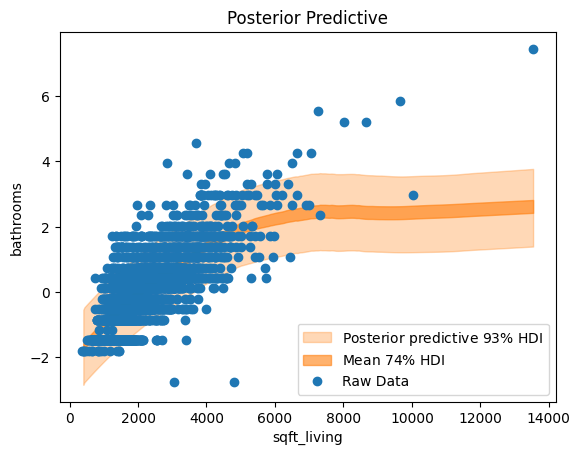

In [34]:
x_plot = X["sqft_living"].to_numpy()
idx = np.argsort(x_plot)

fig, ax = plt.subplots()

az.plot_hdi(
    x=x_plot[idx],
    y=pps[:, idx],
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=x_plot[idx],
    y=posterior_mean.stack(sample=("chain", "draw")).transpose("sample", ...).values[:, idx],
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)

ax.plot(
    sdsts_nona["sqft_living"],
    Y,
    "o",
    c="C0",
    label="Raw Data"
)

ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="sqft_living",
    ylabel="bathrooms"
);

In [37]:
vars = pmb.compute_variable_importance(idata_house3, mu, X)

<Axes: ylabel='R²'>

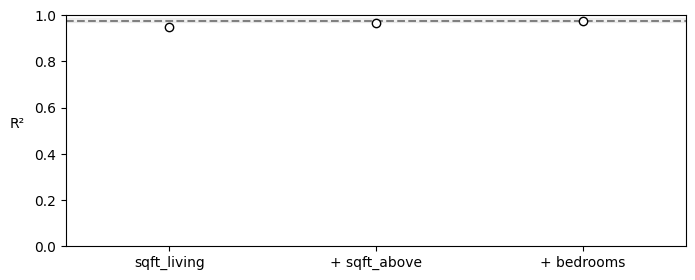

In [38]:
pmb.plot_variable_importance(vars)

# Conclusion

Overall, my variables' importance depended on how many trees. More trees led to similar R^2 results. As far as performance goes, based on the scatter predictions I was decently happy with the results. The second half of the graphs weren't very good, but considering how predicting the number of bathrooms can be so variable, I thought the models showed the behavior pretty well.

I tried running plot posterior predicitives but these were not useful at all because the nature of bathrooms is discrete and after standardizing, these become standardized values, so the density plot makes a bunch of spikes, while my Normal produces continuous values.